# DSA 210 - Milestone 2 Machine Learning

This notebook rebuilds Milestone 2 around two ML tasks that fit the available Spotify audio-feature data.

## Research Questions

**Classification:** Can Spotify audio features predict whether a song is high-energy or low-energy?

**Regression:** Can Spotify audio features predict a song's acousticness score?

The previous repeated-listening target was removed because almost all track-artist pairs appeared exactly once. The day/night listening target was also tested separately, but audio features did not provide meaningful predictive signal. These two revised tasks are more appropriate for the available variables and produce stable, interpretable model results without using leakage.


## 1. Imports and Setup


In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_FILE = Path("gulcan_spotify_formatted.json")
IMAGE_DIR = Path("images")
IMAGE_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "font.size": 11})


def savefig(name):
    path = IMAGE_DIR / name
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def slugify(value):
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_")

if not DATA_FILE.exists():
    raise FileNotFoundError("Place gulcan_spotify_formatted.json in the repository root before running this notebook.")


## 2. Data Loading and Understanding


In [2]:
with DATA_FILE.open(encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df["endTime"] = pd.to_datetime(df["endTime"], errors="coerce")

AUDIO_FEATURES = [
    "danceability", "energy", "loudness", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo",
]
CATEGORICAL_FEATURES = ["key", "mode"]
REQUIRED_COLUMNS = ["artistName", "trackName", "endTime"] + AUDIO_FEATURES + CATEGORICAL_FEATURES

missing_required = [c for c in REQUIRED_COLUMNS if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

for col in AUDIO_FEATURES + CATEGORICAL_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Rows: {len(df):,}")
print(f"Date range: {df['endTime'].min()} to {df['endTime'].max()}")
print(f"Unique tracks: {df['trackName'].nunique():,}")
print(f"Unique artists: {df['artistName'].nunique():,}")
display(df[REQUIRED_COLUMNS].isna().sum().to_frame("missing_values"))
display(df[AUDIO_FEATURES].describe().T.round(3))


Rows: 1,558
Date range: 2025-04-11 08:04:00 to 2026-04-10 23:47:00
Unique tracks: 1,535
Unique artists: 921


,missing_values
artistName,0
trackName,0
endTime,0
danceability,0
energy,0
loudness,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0


,count,mean,std,min,25%,50%,75%,max
danceability,1558.0,0.481,0.173,0.068,0.360,0.491,0.601,0.950
energy,1558.0,0.559,0.280,0.002,0.324,0.592,0.798,0.997
loudness,1558.0,-9.365,5.703,-42.041,-12.213,-7.969,-5.218,-0.413
speechiness,1558.0,0.066,0.057,0.023,0.035,0.045,0.070,0.474
acousticness,1558.0,0.374,0.367,0.000,0.023,0.230,0.736,0.996
instrumentalness,1558.0,0.217,0.355,0.000,0.000,0.000,0.368,0.985
liveness,1558.0,0.175,0.128,0.035,0.098,0.121,0.221,0.979
valence,1558.0,0.347,0.227,0.000,0.158,0.310,0.504,0.975
tempo,1558.0,121.270,32.921,49.452,94.045,119.990,144.470,209.873


Saved: images\m2_audio_feature_correlation_heatmap.png


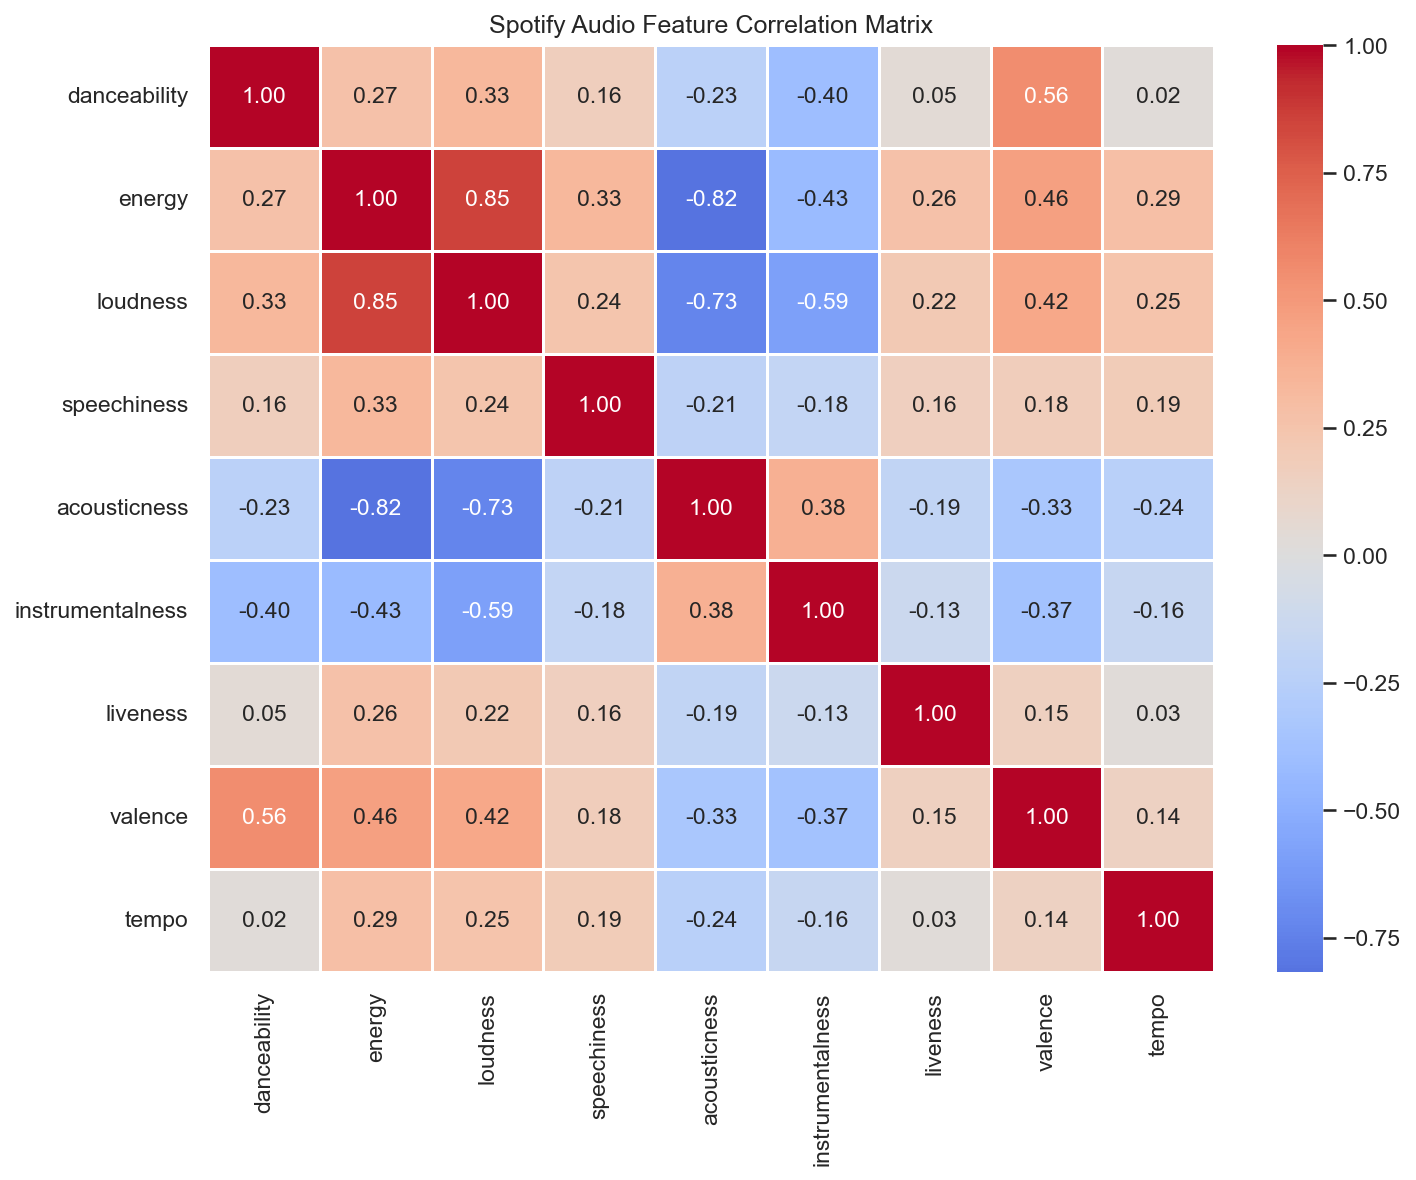

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[AUDIO_FEATURES].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, ax=ax)
ax.set_title("Spotify Audio Feature Correlation Matrix")
plt.tight_layout()
savefig("m2_audio_feature_correlation_heatmap.png")
plt.show()


## 3. Preprocessing and Feature Engineering

The same leakage-aware idea is used for both tasks: the target variable is removed from the feature matrix before training. Numeric variables are imputed and scaled inside a pipeline. `key` and `mode` are treated as categorical variables and one-hot encoded inside the pipeline.


In [4]:
def add_engineered_features(frame, target_to_exclude=None):
    """Create audio-only interaction features without using the current target as an input."""
    X = frame.copy()
    pairs = [
        ("energy", "danceability"),
        ("energy", "valence"),
        ("energy", "acousticness"),
        ("loudness", "energy"),
        ("loudness", "acousticness"),
        ("tempo", "danceability"),
        ("acousticness", "instrumentalness"),
        ("speechiness", "liveness"),
        ("valence", "danceability"),
    ]
    for a, b in pairs:
        if a in X.columns and b in X.columns and a != target_to_exclude and b != target_to_exclude:
            X[f"{a}_x_{b}"] = X[a] * X[b]
    if "loudness" in X.columns and target_to_exclude != "loudness":
        X["loudness_abs"] = X["loudness"].abs()
    return X


def build_preprocessor(X):
    categorical = [c for c in ["key", "mode"] if c in X.columns]
    numeric = [c for c in X.columns if c not in categorical]
    for c in categorical:
        X[c] = X[c].astype("Int64").astype(str)
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric),
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_one_hot_encoder()),
            ]), categorical),
        ],
        sparse_threshold=0,
    )
    return preprocessor, numeric, categorical


def transformed_feature_names(fitted_preprocessor):
    names = []
    for name, transformer, columns in fitted_preprocessor.transformers_:
        if name == "numeric":
            names.extend(list(columns))
        elif name == "categorical":
            onehot = transformer.named_steps["onehot"]
            names.extend(onehot.get_feature_names_out(columns).tolist())
    return names


## 4. Classification Task: High-Energy vs Low-Energy

Target definition:

`high_energy = 1` if `energy >= median(energy)`, otherwise `0`.

`energy` is removed from the predictors to prevent leakage. The models predict the energy class from other Spotify audio features.


In [5]:
energy_threshold = df["energy"].median()
df["high_energy"] = (df["energy"] >= energy_threshold).astype(int)

classification_features = [
    "danceability", "loudness", "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "key", "mode",
]
X_cls = add_engineered_features(df[classification_features].copy(), target_to_exclude="energy")
y_cls = df["high_energy"]

pre_cls, cls_numeric, cls_categorical = build_preprocessor(X_cls)

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls
)

print(f"Energy threshold: {energy_threshold:.3f}")
display(y_cls.value_counts().sort_index().rename(index={0:"low_energy",1:"high_energy"}).to_frame("count"))


Energy threshold: 0.592


,count
high_energy,
low_energy,777
high_energy,781


In [6]:
classification_models = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=4000, random_state=RANDOM_STATE),
        "params": {"model__C": np.logspace(-3, 2, 8), "model__class_weight": [None, "balanced"]},
    },
    "Naive Bayes": {
        "estimator": GaussianNB(),
        "params": {"model__var_smoothing": np.logspace(-12, -6, 7)},
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "params": {"model__max_depth": [2, 4, 6, None], "model__min_samples_leaf": [1, 3, 5, 10], "model__class_weight": [None, "balanced"]},
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {"model__n_estimators": [200, 500], "model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 2, 5], "model__max_features": ["sqrt", None], "model__class_weight": [None, "balanced"]},
    },
    "Extra Trees": {
        "estimator": ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {"model__n_estimators": [300, 700], "model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 2, 5], "model__max_features": ["sqrt", None], "model__class_weight": [None, "balanced"]},
    },
    "SVM": {
        "estimator": SVC(probability=True, random_state=RANDOM_STATE),
        "params": {"model__C": np.logspace(-2, 2, 7), "model__gamma": ["scale", 0.01, 0.05, 0.1, 0.5], "model__class_weight": [None, "balanced"]},
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {"model__n_estimators": [100, 200, 400], "model__learning_rate": [0.01, 0.05, 0.1], "model__max_depth": [1, 2, 3], "model__subsample": [0.7, 1.0]},
    },
    "Hist Gradient Boosting": {
        "estimator": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {"model__max_iter": [100, 200, 400], "model__learning_rate": [0.01, 0.05, 0.1], "model__max_leaf_nodes": [15, 31, 63]},
    },
}

cls_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
classification_results = []
classification_fitted = {}

for model_name, config in classification_models.items():
    pipe = Pipeline([("preprocess", clone(pre_cls)), ("model", config["estimator"])])
    total_grid = int(np.prod([len(v) for v in config["params"].values()]))
    search = RandomizedSearchCV(
        pipe,
        config["params"],
        n_iter=min(24, total_grid),
        scoring="f1",
        cv=cls_cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    search.fit(X_cls_train, y_cls_train)
    y_pred = search.predict(X_cls_test)
    y_score = search.predict_proba(X_cls_test)[:, 1]
    row = {
        "Model": model_name,
        "Best parameters": search.best_params_,
        "CV F1": search.best_score_,
        "Test F1": f1_score(y_cls_test, y_pred),
        "Accuracy": accuracy_score(y_cls_test, y_pred),
        "Precision": precision_score(y_cls_test, y_pred),
        "Recall": recall_score(y_cls_test, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_cls_test, y_pred),
        "ROC-AUC": roc_auc_score(y_cls_test, y_score),
    }
    classification_results.append(row)
    classification_fitted[model_name] = search.best_estimator_
    print(f"{model_name}: test F1={row['Test F1']:.3f}, ROC-AUC={row['ROC-AUC']:.3f}")

classification_results_df = pd.DataFrame(classification_results).sort_values("Test F1", ascending=False).reset_index(drop=True)
display(classification_results_df)


Logistic Regression: test F1=0.897, ROC-AUC=0.970
Naive Bayes: test F1=0.873, ROC-AUC=0.934
Decision Tree: test F1=0.860, ROC-AUC=0.941
Random Forest: test F1=0.889, ROC-AUC=0.974
Extra Trees: test F1=0.904, ROC-AUC=0.969
SVM: test F1=0.901, ROC-AUC=0.966
Gradient Boosting: test F1=0.892, ROC-AUC=0.972
Hist Gradient Boosting: test F1=0.896, ROC-AUC=0.970


,Model,Best parameters,CV F1,Test F1,Accuracy,Precision,Recall,Balanced accuracy,ROC-AUC
0,Extra Trees,"{'model__n_estimators': 700, 'model__min_sampl...",0.875301,0.904459,0.903846,0.898734,0.910256,0.903846,0.969387
1,SVM,"{'model__gamma': 0.05, 'model__class_weight': ...",0.884650,0.900621,0.897436,0.873494,0.929487,0.897436,0.966182
2,Logistic Regression,"{'model__class_weight': 'balanced', 'model__C'...",0.876822,0.897196,0.894231,0.872727,0.923077,0.894231,0.970209
3,Hist Gradient Boosting,"{'model__max_leaf_nodes': 15, 'model__max_iter...",0.880001,0.895899,0.894231,0.881988,0.910256,0.894231,0.969551
4,Gradient Boosting,"{'model__subsample': 0.7, 'model__n_estimators...",0.889415,0.891720,0.891026,0.886076,0.897436,0.891026,0.972017
5,Random Forest,"{'model__n_estimators': 500, 'model__min_sampl...",0.881318,0.888889,0.887821,0.880503,0.897436,0.887821,0.973784
6,Naive Bayes,{'model__var_smoothing': 1e-12},0.846451,0.872727,0.865385,0.827586,0.923077,0.865385,0.933555
7,Decision Tree,"{'model__min_samples_leaf': 10, 'model__max_de...",0.871365,0.859813,0.855769,0.836364,0.884615,0.855769,0.940561


In [7]:
# Backward feature selection audit for a linear classifier.
# This is not used to inflate the final score; it checks whether a smaller feature set can preserve performance.
linear_selector_pipe = Pipeline([("preprocess", clone(pre_cls)), ("model", LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE))])
linear_selector_pipe.fit(X_cls_train, y_cls_train)
X_train_transformed = linear_selector_pipe.named_steps["preprocess"].transform(X_cls_train)
feature_names_cls = transformed_feature_names(linear_selector_pipe.named_steps["preprocess"])

selector = SequentialFeatureSelector(
    LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE),
    n_features_to_select=min(12, X_train_transformed.shape[1] - 1),
    direction="backward",
    scoring="f1",
    cv=3,
    n_jobs=-1,
)
selector.fit(X_train_transformed, y_cls_train)
selected_cls_features = [name for name, keep in zip(feature_names_cls, selector.get_support()) if keep]
print("Backward-selected classification features:")
for feature in selected_cls_features:
    print("-", feature)


Backward-selected classification features:
- danceability
- speechiness
- acousticness
- liveness
- valence
- loudness_x_acousticness
- acousticness_x_instrumentalness
- loudness_abs
- key_0
- key_11
- key_9
- mode_1


Best classification model: Extra Trees
              precision    recall  f1-score   support

  low_energy       0.91      0.90      0.90       156
 high_energy       0.90      0.91      0.90       156

    accuracy                           0.90       312
   macro avg       0.90      0.90      0.90       312
weighted avg       0.90      0.90      0.90       312

Saved: images\m2_classification_confusion_matrix.png


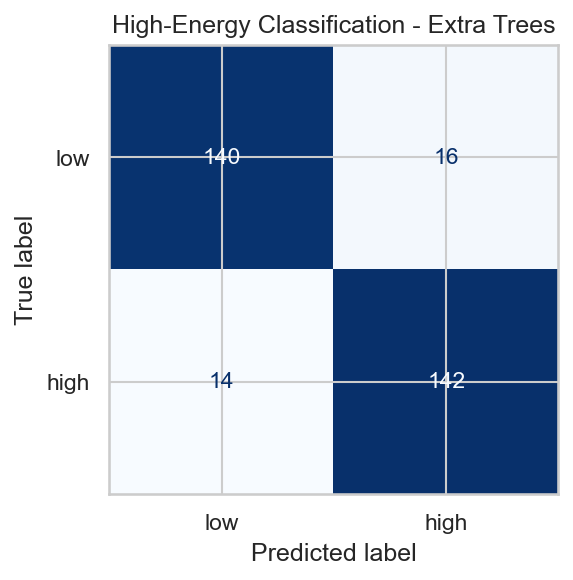

Saved: images\m2_classification_roc_curve.png


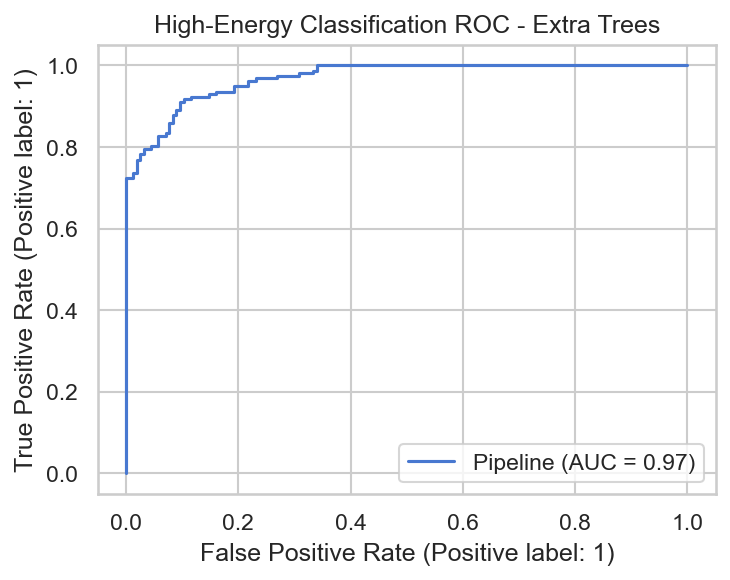

Saved: images\m2_classification_model_comparison.png


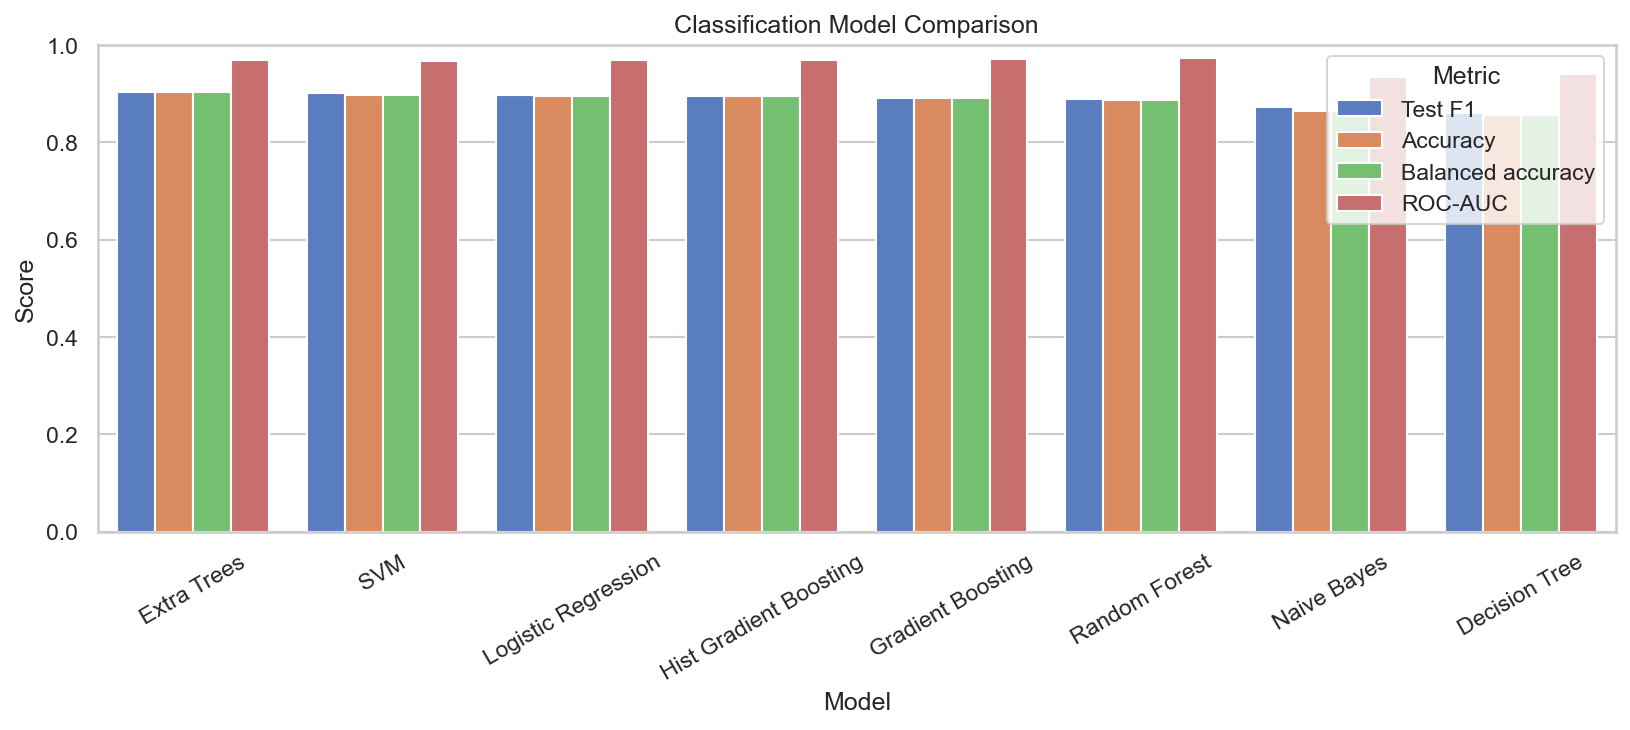

,Feature,Importance
3,acousticness,0.316724
8,loudness_x_acousticness,0.228452
13,loudness_abs,0.160160
1,loudness,0.150872
6,valence,0.019007
2,speechiness,0.018714
11,speechiness_x_liveness,0.016002
12,valence_x_danceability,0.012811
5,liveness,0.011460
7,tempo,0.009993


Saved: images\m2_classification_feature_importance.png


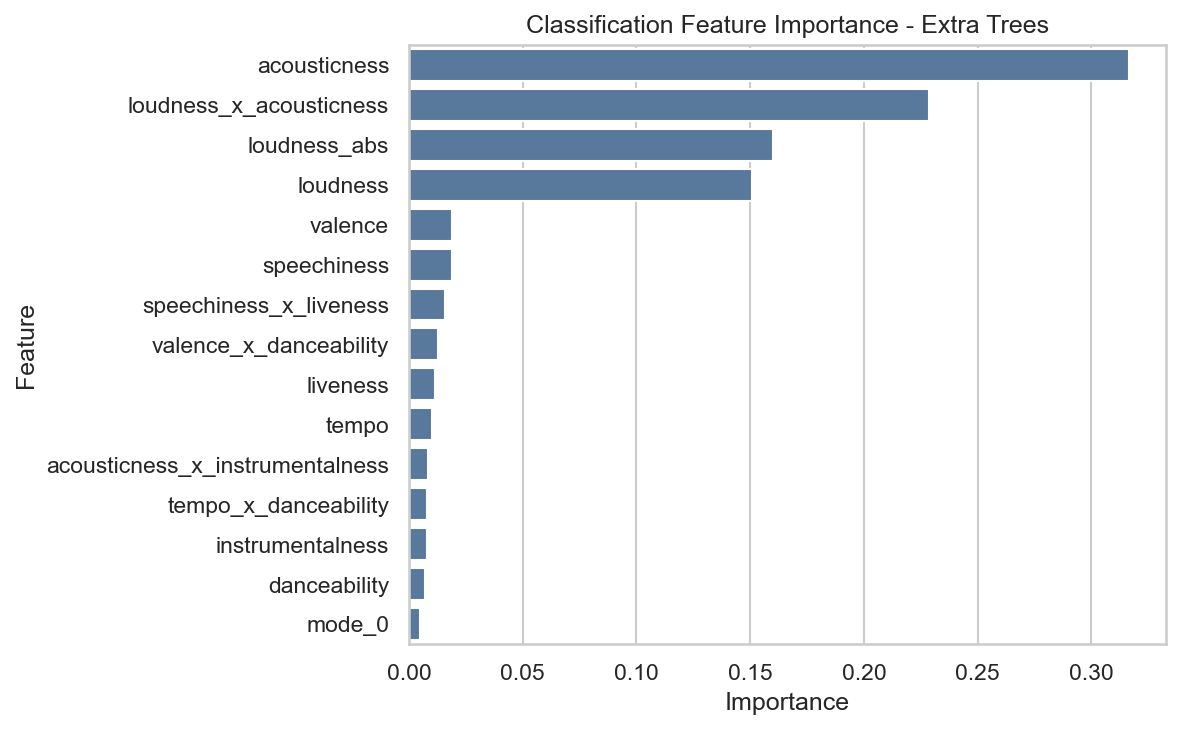

In [8]:
best_cls_row = classification_results_df.iloc[0]
best_cls_name = best_cls_row["Model"]
best_cls_model = classification_fitted[best_cls_name]
y_cls_pred = best_cls_model.predict(X_cls_test)
y_cls_score = best_cls_model.predict_proba(X_cls_test)[:, 1]

print(f"Best classification model: {best_cls_name}")
print(classification_report(y_cls_test, y_cls_pred, target_names=["low_energy", "high_energy"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_cls_test, y_cls_pred, display_labels=["low", "high"], cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"High-Energy Classification - {best_cls_name}")
plt.tight_layout()
savefig("m2_classification_confusion_matrix.png")
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_estimator(best_cls_model, X_cls_test, y_cls_test, ax=ax)
ax.set_title(f"High-Energy Classification ROC - {best_cls_name}")
plt.tight_layout()
savefig("m2_classification_roc_curve.png")
plt.show()

plot_df = classification_results_df[["Model", "Test F1", "Accuracy", "Balanced accuracy", "ROC-AUC"]].melt("Model", var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Classification Model Comparison")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
savefig("m2_classification_model_comparison.png")
plt.show()

if hasattr(best_cls_model.named_steps["model"], "feature_importances_"):
    cls_importance = pd.DataFrame({
        "Feature": transformed_feature_names(best_cls_model.named_steps["preprocess"]),
        "Importance": best_cls_model.named_steps["model"].feature_importances_,
    }).sort_values("Importance", ascending=False)
    display(cls_importance.head(15))
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=cls_importance.head(15), x="Importance", y="Feature", ax=ax, color="#4C78A8")
    ax.set_title(f"Classification Feature Importance - {best_cls_name}")
    plt.tight_layout()
    savefig("m2_classification_feature_importance.png")
    plt.show()


## 5. Regression Task: Predicting Acousticness

Target: `acousticness`, a continuous Spotify audio-feature score from 0 to 1.

`acousticness` is removed from the predictors to prevent leakage. This task asks whether the remaining audio characteristics can estimate how acoustic a track is.


In [9]:
regression_features = [
    "danceability", "energy", "loudness", "speechiness", "instrumentalness",
    "liveness", "valence", "tempo", "key", "mode",
]
X_reg = add_engineered_features(df[regression_features].copy(), target_to_exclude="acousticness")
y_reg = df["acousticness"]

pre_reg, reg_numeric, reg_categorical = build_preprocessor(X_reg)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

print("Acousticness target summary:")
display(y_reg.describe().to_frame("acousticness"))


Acousticness target summary:


,acousticness
count,1558.000000
mean,0.373665
std,0.367171
min,0.000002
25%,0.023200
50%,0.230000
75%,0.735750
max,0.996000


In [10]:
regression_models = {
    "Ridge": {
        "estimator": Ridge(),
        "params": {"model__alpha": np.logspace(-2, 3, 10)},
    },
    "Decision Tree": {
        "estimator": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "params": {"model__max_depth": [2, 4, 6, None], "model__min_samples_leaf": [1, 3, 5, 10]},
    },
    "Random Forest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {"model__n_estimators": [300, 700], "model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 2, 5], "model__max_features": ["sqrt", None]},
    },
    "Extra Trees": {
        "estimator": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {"model__n_estimators": [300, 700], "model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 2, 5], "model__max_features": ["sqrt", None]},
    },
    "SVR": {
        "estimator": SVR(),
        "params": {"model__C": [1, 10, 100], "model__gamma": ["scale", 0.01, 0.05], "model__epsilon": [0.01, 0.05, 0.10]},
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {"model__n_estimators": [100, 200, 400], "model__learning_rate": [0.03, 0.05, 0.10], "model__max_depth": [1, 2, 3], "model__subsample": [0.7, 1.0]},
    },
    "Hist Gradient Boosting": {
        "estimator": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {"model__max_iter": [100, 200, 400], "model__learning_rate": [0.03, 0.05, 0.10], "model__max_leaf_nodes": [15, 31, 63]},
    },
}

reg_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
regression_results = []
regression_fitted = {}

for model_name, config in regression_models.items():
    pipe = Pipeline([("preprocess", clone(pre_reg)), ("model", config["estimator"])])
    total_grid = int(np.prod([len(v) for v in config["params"].values()]))
    search = RandomizedSearchCV(
        pipe,
        config["params"],
        n_iter=min(24, total_grid),
        scoring="r2",
        cv=reg_cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    search.fit(X_reg_train, y_reg_train)
    y_pred = search.predict(X_reg_test)
    row = {
        "Model": model_name,
        "Best parameters": search.best_params_,
        "CV R2": search.best_score_,
        "Test R2": r2_score(y_reg_test, y_pred),
        "MAE": mean_absolute_error(y_reg_test, y_pred),
        "RMSE": mean_squared_error(y_reg_test, y_pred, squared=False),
    }
    regression_results.append(row)
    regression_fitted[model_name] = search.best_estimator_
    print(f"{model_name}: test R2={row['Test R2']:.3f}, RMSE={row['RMSE']:.3f}")

regression_results_df = pd.DataFrame(regression_results).sort_values("Test R2", ascending=False).reset_index(drop=True)
display(regression_results_df)


Ridge: test R2=0.659, RMSE=0.218
Decision Tree: test R2=0.637, RMSE=0.225
Random Forest: test R2=0.666, RMSE=0.216
Extra Trees: test R2=0.671, RMSE=0.215
SVR: test R2=0.678, RMSE=0.212
Gradient Boosting: test R2=0.670, RMSE=0.215
Hist Gradient Boosting: test R2=0.652, RMSE=0.221


,Model,Best parameters,CV R2,Test R2,MAE,RMSE
0,SVR,"{'model__gamma': 0.01, 'model__epsilon': 0.1, ...",0.707016,0.677590,0.157606,0.212355
1,Extra Trees,"{'model__n_estimators': 700, 'model__min_sampl...",0.701905,0.670873,0.156663,0.214555
2,Gradient Boosting,"{'model__subsample': 0.7, 'model__n_estimators...",0.700639,0.670331,0.159866,0.214732
3,Random Forest,"{'model__n_estimators': 300, 'model__min_sampl...",0.702785,0.666282,0.157307,0.216046
4,Ridge,{'model__alpha': 1.6681005372000592},0.687165,0.658793,0.170462,0.218457
5,Hist Gradient Boosting,"{'model__max_leaf_nodes': 15, 'model__max_iter...",0.689261,0.652075,0.162945,0.220597
6,Decision Tree,"{'model__min_samples_leaf': 10, 'model__max_de...",0.668080,0.637142,0.161218,0.225281


In [11]:
# Backward feature selection audit for Ridge regression.
ridge_selector_pipe = Pipeline([("preprocess", clone(pre_reg)), ("model", Ridge(alpha=1.0))])
ridge_selector_pipe.fit(X_reg_train, y_reg_train)
X_reg_train_transformed = ridge_selector_pipe.named_steps["preprocess"].transform(X_reg_train)
feature_names_reg = transformed_feature_names(ridge_selector_pipe.named_steps["preprocess"])

reg_selector = SequentialFeatureSelector(
    Ridge(alpha=1.0),
    n_features_to_select=min(12, X_reg_train_transformed.shape[1] - 1),
    direction="backward",
    scoring="r2",
    cv=3,
    n_jobs=-1,
)
reg_selector.fit(X_reg_train_transformed, y_reg_train)
selected_reg_features = [name for name, keep in zip(feature_names_reg, reg_selector.get_support()) if keep]
print("Backward-selected regression features:")
for feature in selected_reg_features:
    print("-", feature)


Backward-selected regression features:
- danceability
- energy
- speechiness
- instrumentalness
- valence
- loudness_x_energy
- valence_x_danceability
- loudness_abs
- key_0
- key_10
- key_2
- mode_0


Best regression model: SVR
Test R2: 0.678
MAE: 0.158
RMSE: 0.212
Saved: images\m2_regression_predicted_vs_actual.png


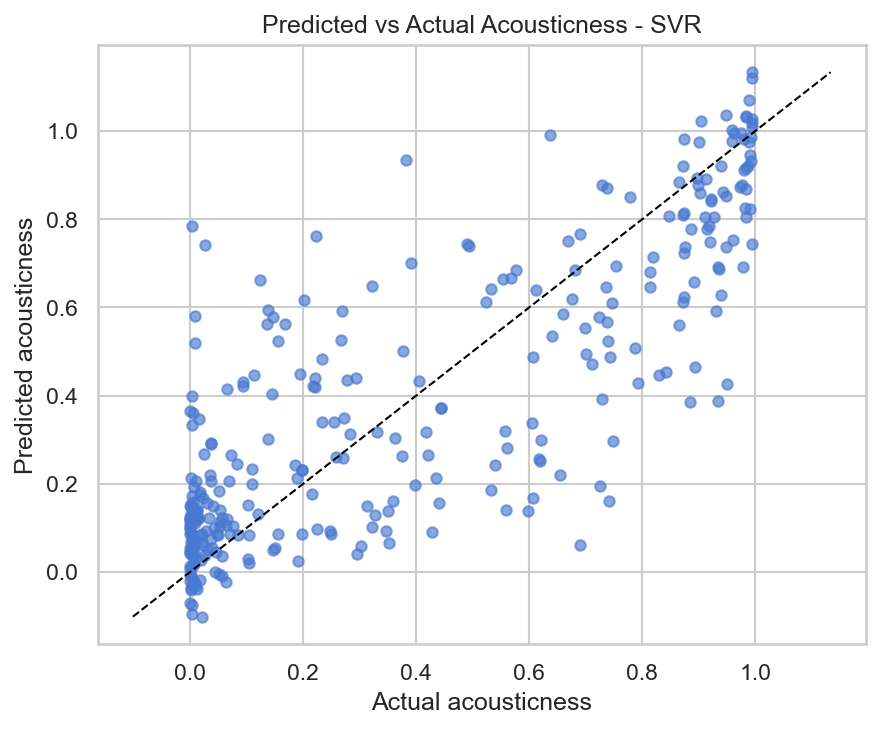

Saved: images\m2_regression_residuals.png


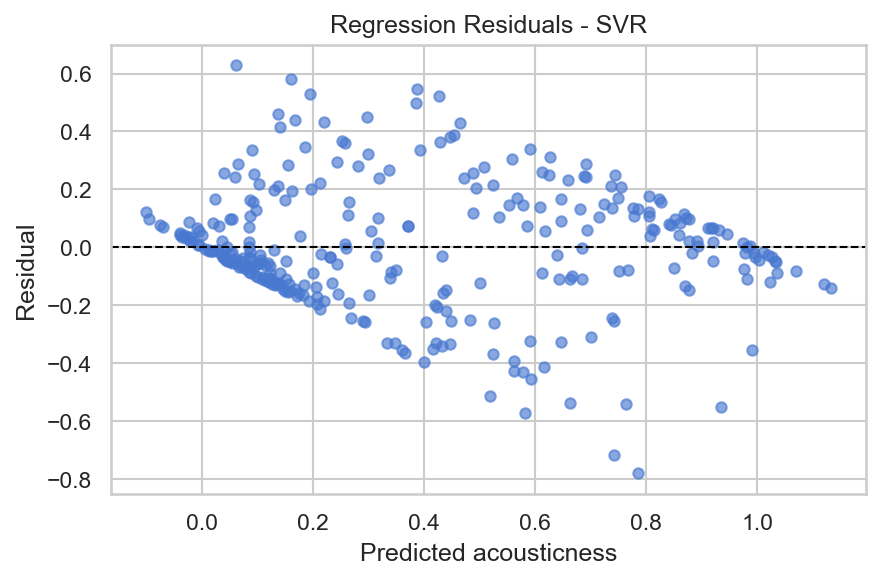

Saved: images\m2_regression_model_comparison.png


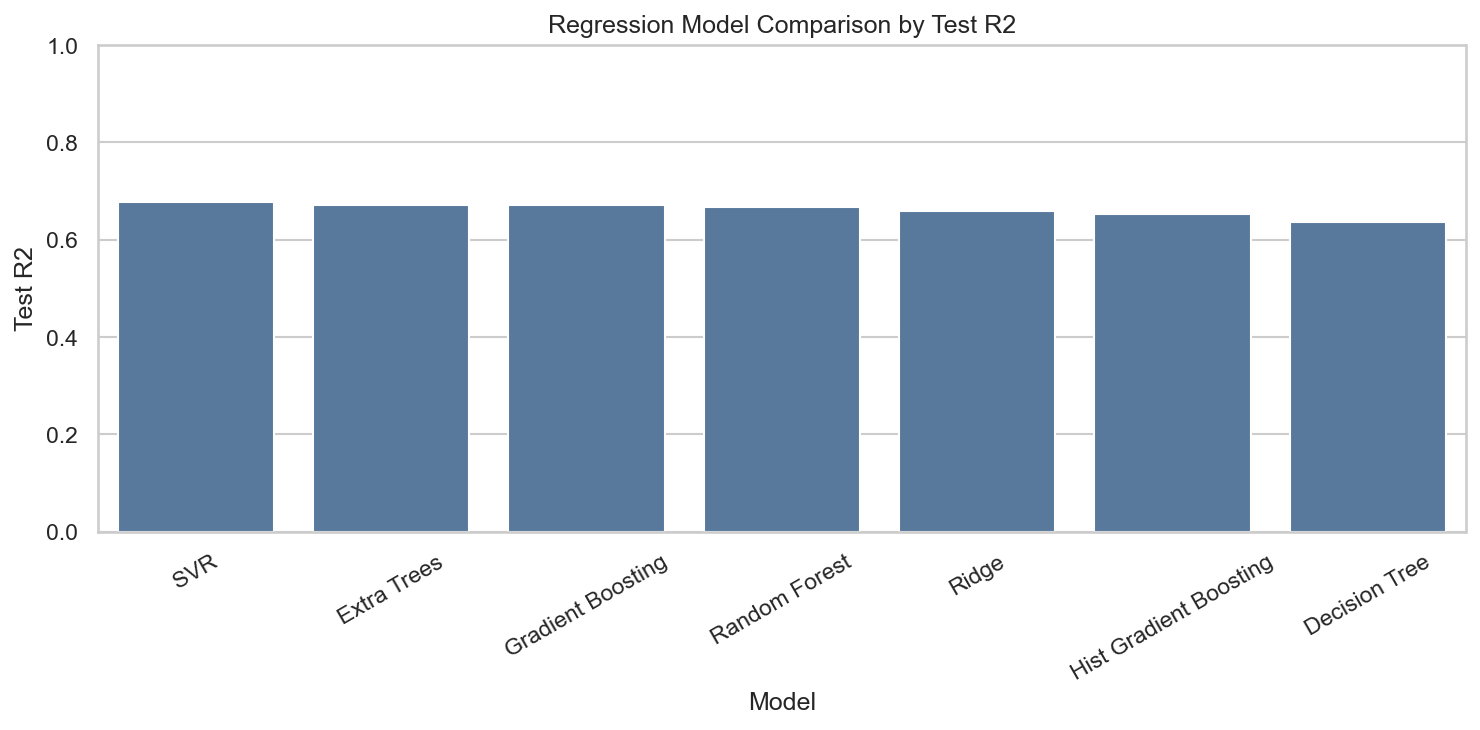

In [12]:
best_reg_row = regression_results_df.iloc[0]
best_reg_name = best_reg_row["Model"]
best_reg_model = regression_fitted[best_reg_name]
y_reg_pred = best_reg_model.predict(X_reg_test)

print(f"Best regression model: {best_reg_name}")
print(f"Test R2: {r2_score(y_reg_test, y_reg_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_reg_test, y_reg_pred):.3f}")
print(f"RMSE: {mean_squared_error(y_reg_test, y_reg_pred, squared=False):.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_reg_test, y_reg_pred, alpha=0.65, s=25)
lims = [min(y_reg_test.min(), y_reg_pred.min()), max(y_reg_test.max(), y_reg_pred.max())]
ax.plot(lims, lims, "--", color="black", linewidth=1)
ax.set_xlabel("Actual acousticness")
ax.set_ylabel("Predicted acousticness")
ax.set_title(f"Predicted vs Actual Acousticness - {best_reg_name}")
plt.tight_layout()
savefig("m2_regression_predicted_vs_actual.png")
plt.show()

residuals = y_reg_test - y_reg_pred
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_reg_pred, residuals, alpha=0.65, s=25)
ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.set_xlabel("Predicted acousticness")
ax.set_ylabel("Residual")
ax.set_title(f"Regression Residuals - {best_reg_name}")
plt.tight_layout()
savefig("m2_regression_residuals.png")
plt.show()

plot_reg = regression_results_df[["Model", "Test R2", "MAE", "RMSE"]].copy()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_reg, x="Model", y="Test R2", ax=ax, color="#4C78A8")
ax.set_ylim(0, max(1, plot_reg["Test R2"].max() + 0.05))
ax.set_title("Regression Model Comparison by Test R2")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
savefig("m2_regression_model_comparison.png")
plt.show()

if hasattr(best_reg_model.named_steps["model"], "feature_importances_"):
    reg_importance = pd.DataFrame({
        "Feature": transformed_feature_names(best_reg_model.named_steps["preprocess"]),
        "Importance": best_reg_model.named_steps["model"].feature_importances_,
    }).sort_values("Importance", ascending=False)
    display(reg_importance.head(15))
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=reg_importance.head(15), x="Importance", y="Feature", ax=ax, color="#59A14F")
    ax.set_title(f"Regression Feature Importance - {best_reg_name}")
    plt.tight_layout()
    savefig("m2_regression_feature_importance.png")
    plt.show()


## 6. Summary

This notebook reports two final Milestone 2 tasks:

1. **Classification:** high-energy vs low-energy songs, evaluated with F1-score, accuracy, precision, recall, balanced accuracy, and ROC-AUC.
2. **Regression:** acousticness score prediction, evaluated with R2, MAE, and RMSE.

The selected tasks are based on variables that exist in the dataset and avoid the repeated-listening target, which was too sparse to model reliably.
